In [1]:
#Karthick N 24BAD055
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
#Load dataset
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#Data preprocessing
df = df.dropna()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [4]:
#Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

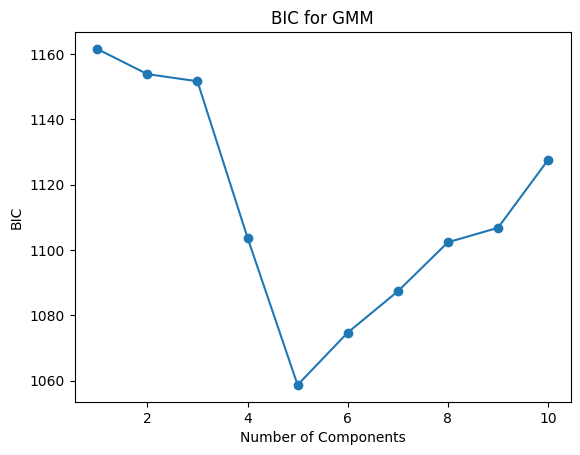

In [5]:
#Choose Number of Components
bic_scores = []
k_range = range(1, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.plot(k_range, bic_scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC for GMM")
plt.show()

In [6]:
#Apply GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [ ]:
#Predict Cluster probabilities
probabilities = gmm.predict_proba(X_scaled)
probabilities[:5]12

array([[1.57689698e-05, 1.88009163e-08, 9.52031247e-04, 5.20013085e-08,
        9.99032129e-01],
       [1.62776204e-05, 1.89596786e-04, 9.99790184e-01, 4.21013390e-23,
        3.94154449e-06],
       [2.21339374e-19, 9.52615737e-19, 1.22549539e-12, 1.86223280e-04,
        9.99813777e-01],
       [1.05444778e-04, 1.80087695e-04, 9.99693745e-01, 3.79390067e-21,
        2.07229768e-05],
       [6.47301428e-05, 3.84273231e-08, 1.55669540e-03, 4.75722704e-08,
        9.98378488e-01]])

In [8]:
#Assign Cluster labels
clusters = gmm.predict(X_scaled)
df['GMM_Cluster'] = clusters
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),GMM_Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


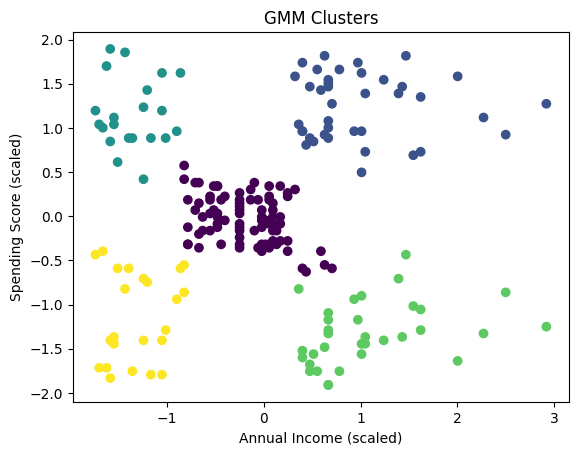

In [9]:
#Visuvalization
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("GMM Clusters")
plt.show()

In [10]:
#Evaluation Metrics
# Log-Likelihood
log_likelihood = gmm.score(X_scaled)
print("Log-Likelihood:", log_likelihood)

# AIC & BIC
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

# Silhouette Score
sil_score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", sil_score)

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


In [11]:
#Cluster interpretation
df.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
GMM_Cluster,,
0,55.642857,49.369048
1,86.538462,82.128205
2,25.095238,80.047619
3,88.818182,16.000000
4,26.304348,20.913043


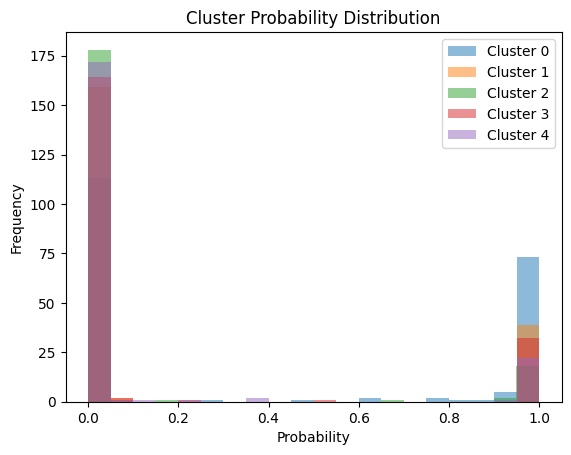

In [14]:
# Plotting histogram 
for i in range(probabilities.shape[1]):
    plt.hist(probabilities[:, i], bins=20, alpha=0.5, label=f'Cluster {i}')

plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.title("Cluster Probability Distribution")
plt.legend()
plt.show()

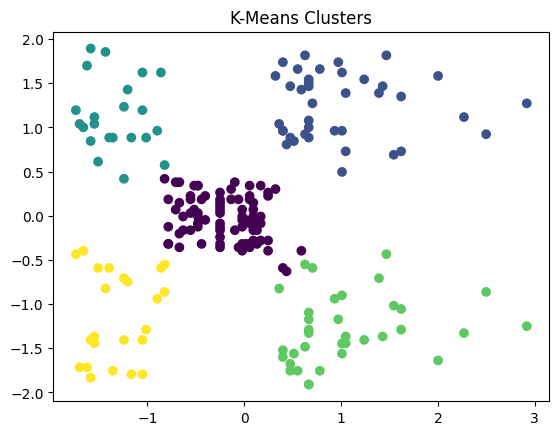

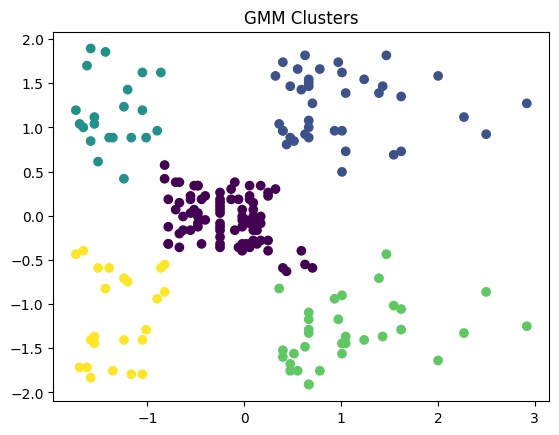

In [12]:
#Compare with K-means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
k_clusters = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=k_clusters)
plt.title("K-Means Clusters")
plt.show()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM Clusters")
plt.show()

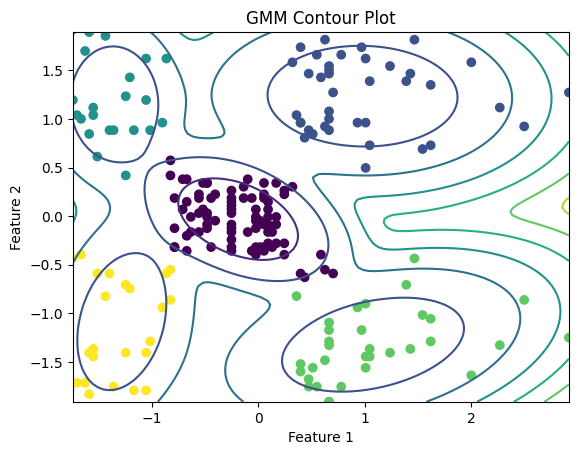

In [13]:
# Create mesh grid
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

# Flatten grid
XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T

# Get log probability
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

# Plot contour
plt.contour(X_grid, Y_grid, Z)

# Plot data points
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)

plt.title("GMM Contour Plot")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()